In [6]:
import sys
!{sys.executable} -m pip install seaborn matplotlib pandas numpy scikit-learn
print("¡Librerías instaladas correctamente!")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


¡Librerías instaladas correctamente!


In [7]:
# ==========================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  

# Protocolo de Esterilización Estético (Estilo limpio sin ruido visual)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120

# Carga del Dataset base
df = pd.read_csv('../data/smart_manufacturing_data.csv') 
print(f"Dimensiones del Dataset: {df.shape[0]} filas, {df.shape[1]} columnas.")
display(df.head())

Dimensiones del Dataset: 100000 filas, 13 columnas.


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


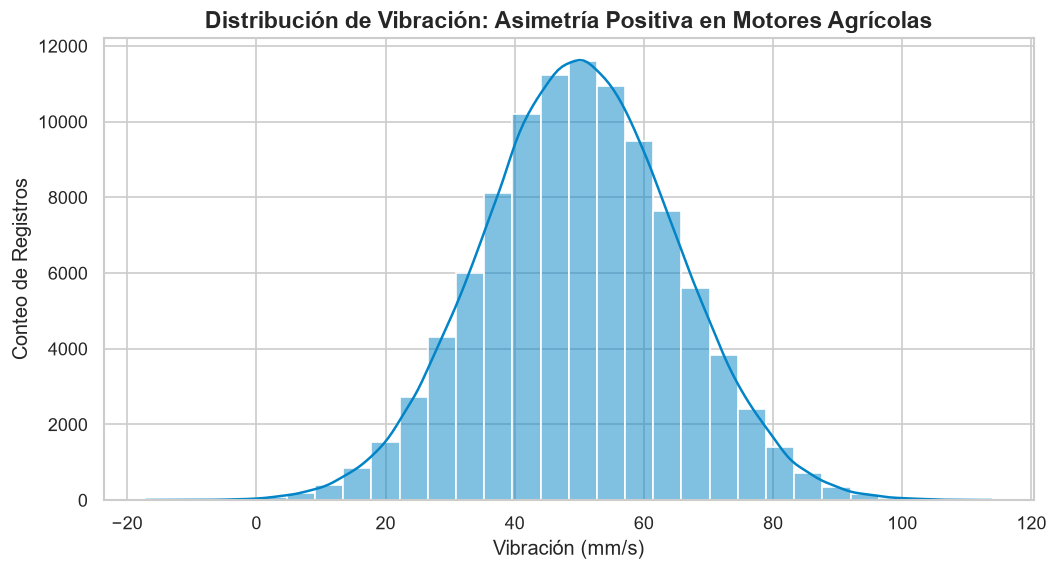

Sesgo (Skewness) de Vibración: 0.01


In [8]:
# ==========================================
# 2. ANÁLISIS UNIVARIADO: HISTOGRAMAS Y KDE
# ==========================================
# Evaluación de asimetría (Skewness) en variables continuas críticas como Vibración
plt.figure(figsize=(10, 5))
sns.histplot(df['vibration'], kde=True, color='#0284c7', bins=30)
plt.title("Distribución de Vibración: Asimetría Positiva en Motores Agrícolas", fontsize=14, fontweight='bold')
plt.xlabel("Vibración (mm/s)")
plt.ylabel("Conteo de Registros")
plt.show()

print(f"Sesgo (Skewness) de Vibración: {df['vibration'].skew():.2f}")

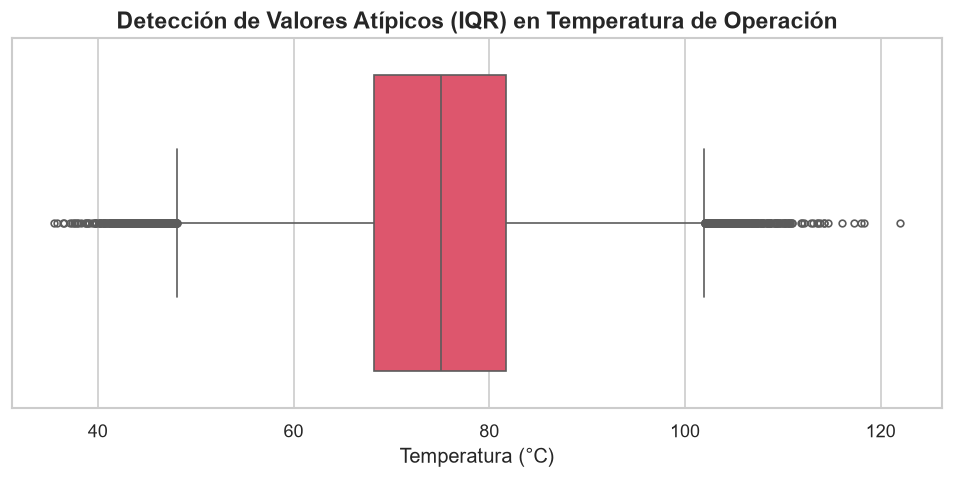

In [9]:
# ==========================================
# 3. DETECCIÓN DE OUTLIERS CON BOXPLOTS (Regla IQR)
# ==========================================
# Identificación visual de picos anómalos en Temperatura
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['temperature'], color='#f43f5e', fliersize=4)
plt.title("Detección de Valores Atípicos (IQR) en Temperatura de Operación", fontsize=14, fontweight='bold')
plt.xlabel("Temperatura (°C)")
plt.show()

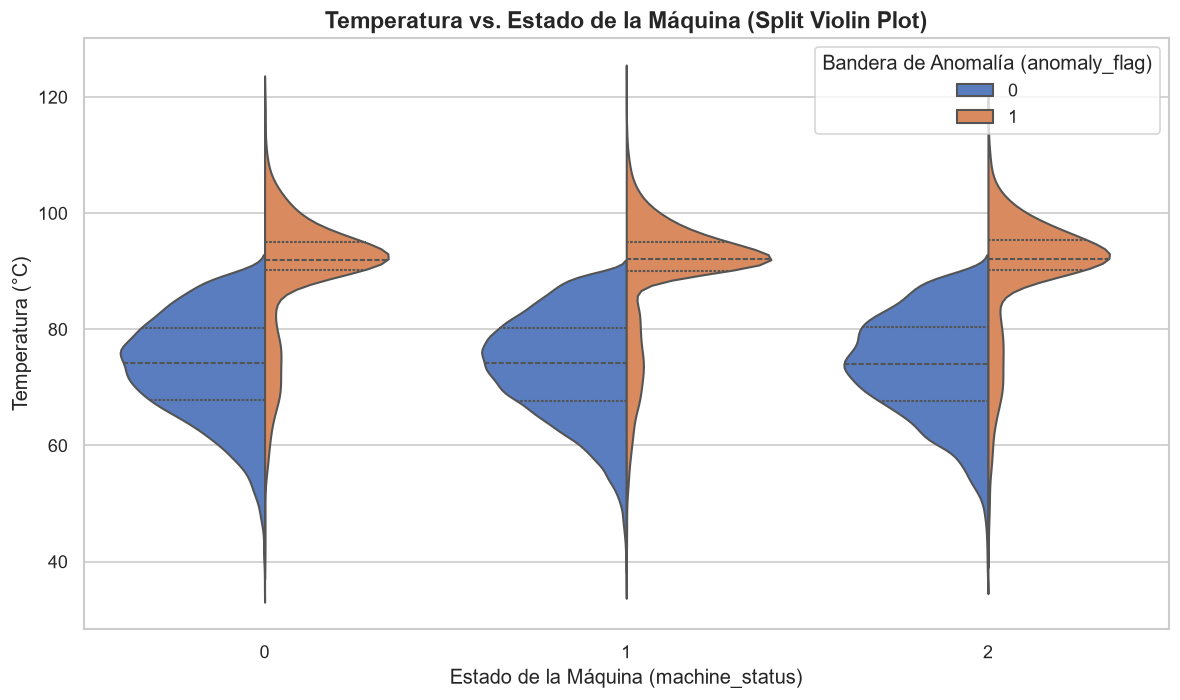

In [12]:
# ==========================================
# 4. ANÁLISIS BIVARIADO: SPLIT VIOLIN PLOT (Corregido con columnas reales)
# ==========================================
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df, 
    x='machine_status', 
    y='temperature', 
    hue='anomaly_flag',  # Usamos la columna real de tu dataset
    split=True, 
    inner='quartile', 
    palette='muted'
)

plt.title("Temperatura vs. Estado de la Máquina (Split Violin Plot)", fontsize=14, fontweight='bold')
plt.xlabel("Estado de la Máquina (machine_status)")
plt.ylabel("Temperatura (°C)")
plt.legend(title="Bandera de Anomalía (anomaly_flag)", loc='upper right')
plt.tight_layout()
plt.show()

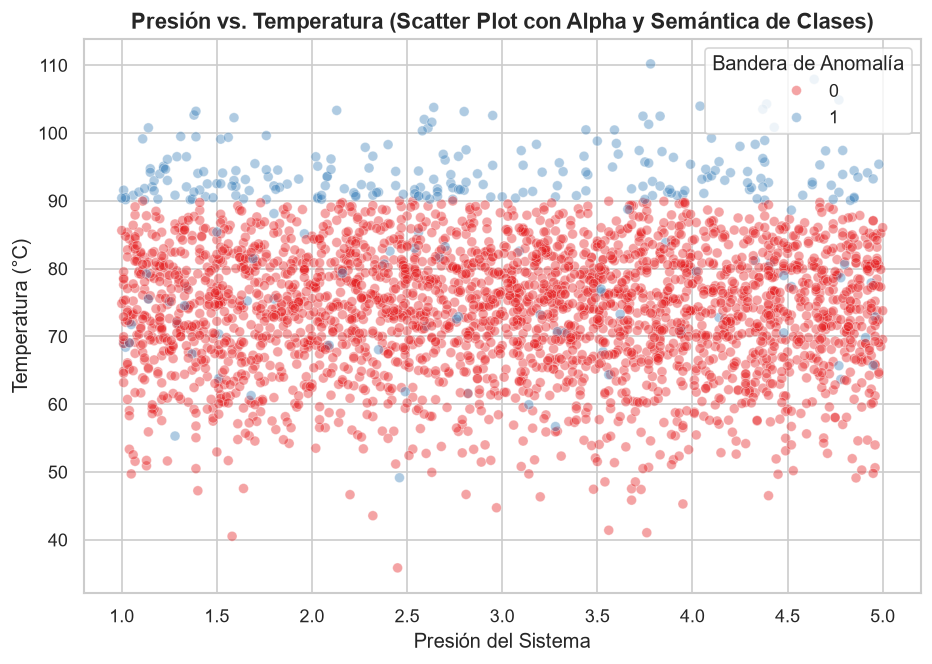

In [13]:
# ==========================================
# 5. SCATTER PLOT MULTIVARIADO CON ALPHA (Control de Overplotting)
# ==========================================
# Ideal para miles de registros sin colapsar visualmente la pantalla
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df.sample(min(3000, len(df)), random_state=42), # Submuestreo preventivo
    x='pressure', 
    y='temperature', 
    hue='anomaly_flag',  # Corregido con la columna real de tu dataset
    alpha=0.4, 
    s=35, 
    palette='Set1'
)
plt.title("Presión vs. Temperatura (Scatter Plot con Alpha y Semántica de Clases)", fontsize=13, fontweight='bold')
plt.xlabel("Presión del Sistema")
plt.ylabel("Temperatura (°C)")
plt.legend(title="Bandera de Anomalía", loc='upper right')
plt.show()

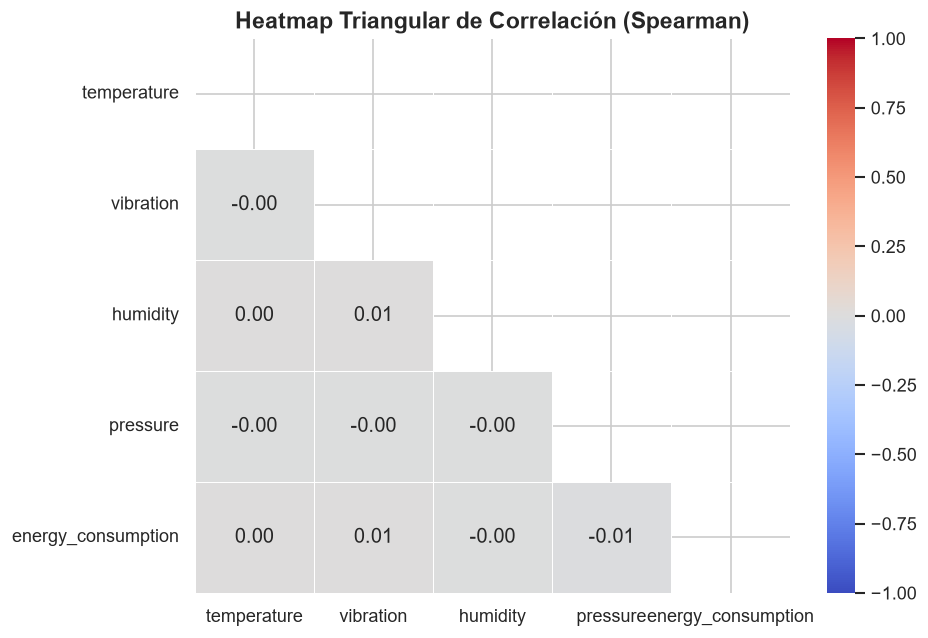

In [14]:
# ==========================================
# 6. MATRICES DE CORRELACIÓN Y HEATMAP TRIANGULAR
# ==========================================
# Aislar solo variables numéricas continuas
cols_numericas = ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption']
corr_matrix = df[cols_numericas].corr(method='spearman') # Spearman robusto ante outliers

# Crear máscara triangular superior para eliminar el espejo redundante
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)
plt.title("Heatmap Triangular de Correlación (Spearman)", fontsize=14, fontweight='bold')
plt.show()